In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.dates as mdates

from pathlib import Path


# Sobe de codigos/ para a raiz do projeto
BASE = Path.cwd().parent         
DADOS = BASE / "dados" / "brutos"
FIGURAS = BASE / "resultados" / "figuras"



In [6]:
#Tratando os dados e montando dataframe
interest_data = pd.read_csv(DADOS/"taxa_de_juros_JPN_praticada.csv",skiprows=4)
interest_data_JPN  = interest_data[interest_data['Country Code'] == 'JPN']
# Remove as colunas especificadas 
japao_filtrado = interest_data_JPN.drop(columns=['Country Code', 'Indicator Name', 'Indicator Code','Country Name'])
# 2. Remove colunaque comece com 'Unnamed'
colunas_validas = [col for col in japao_filtrado.columns if not col.startswith('Unnamed:')]
japao_limpo = japao_filtrado[colunas_validas]
# Transforma em um data frame com duas colunas sendo elas ano e taxa de juros
japao_int_rate = japao_limpo.melt(var_name='Ano', value_name='Taxa de juros real')

# Remove todas as linhas onde a coluna 'Taxa de juros' possui NaN
japao_final = japao_int_rate.dropna(subset=['Taxa de juros real']).reset_index(drop=True)



japao_final.head()






,Ano,Taxa de juros real
0,1993,4.312358
1,1994,3.939249
2,1995,4.050495
3,1996,3.117255
4,1997,1.934613


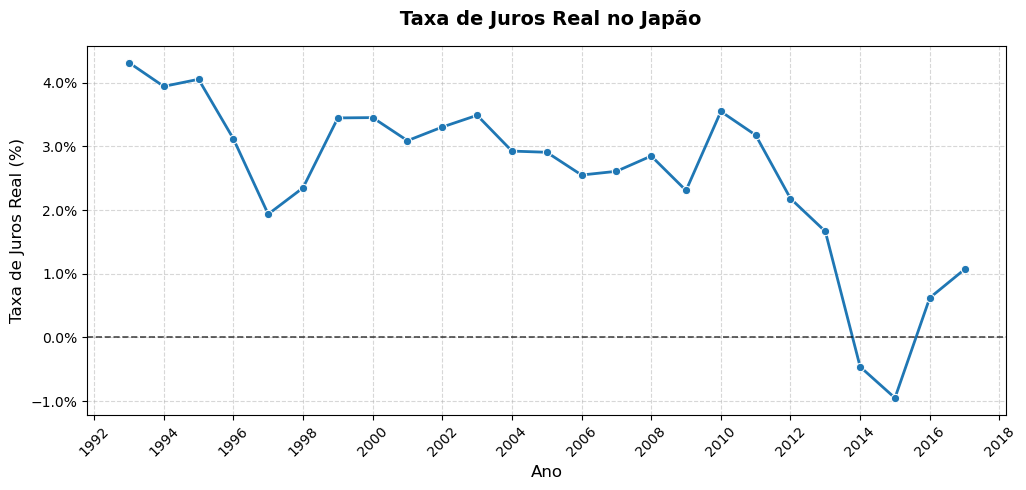

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Garante que a coluna de Ano seja do tipo numérico (inteiro)
japao_final['Ano'] = japao_final['Ano'].astype(int)


# 3. Cria a estrutura do gráfico 
fig, ax = plt.subplots(figsize=(10, 5))

# 4. Desenha o gráfico de linha
sns.lineplot(
    data= japao_final, 
    x='Ano', 
    y='Taxa de juros real', 
    marker='o',       
    color='#1f77b4',  
    linewidth=2,
    ax=ax
)

# 5. Customização de títulos e legendas (legíveis e sem cortes)
ax.set_title(' Taxa de Juros Real no Japão', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Ano', fontsize=12)
ax.set_ylabel('Taxa de Juros Real (%)', fontsize=12)

# Adiciona uma linha preta tracejada exatamente no eixo 0%
plt.axhline(0, color='black', linestyle='--', linewidth=1.2, alpha=0.7)
# 6. Melhoras estéticas adicionais
ax.grid(True, linestyle='--', alpha=0.5) # Linhas de grade suaves ao fundo
plt.xticks(rotation=45)                  # Rotaciona os anos em 45° para não encavalar
plt.tight_layout()                       # Ajusta margens automaticamente para não cortar textos

#Ajustando os intervalos no eixo x
ax.xaxis.set_major_locator(plt.MultipleLocator(2))

#Colocando o eixo y em porcentagem
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100))



# 7. Salva o gráfico como imagem
plt.savefig('grafico_juros_japao.png', dpi=300)

_Gráfico hiato do produto, tx  juros praticada e tx de juros natural_
